Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset Downloaded
/kaggle/input/telco-customer-churn

CSV File:
['/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv']

Dataset Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CSV Saved 

Dataset Shape
(7043, 21)

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Cleaning Completed


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


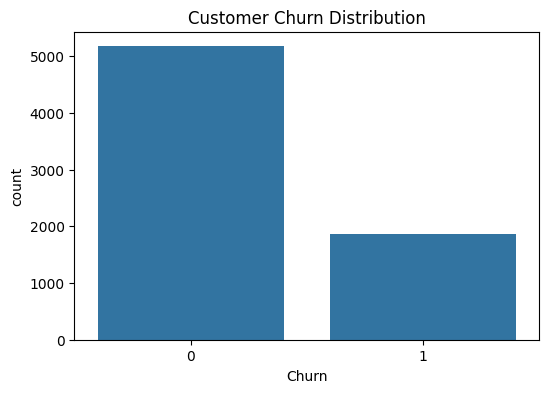

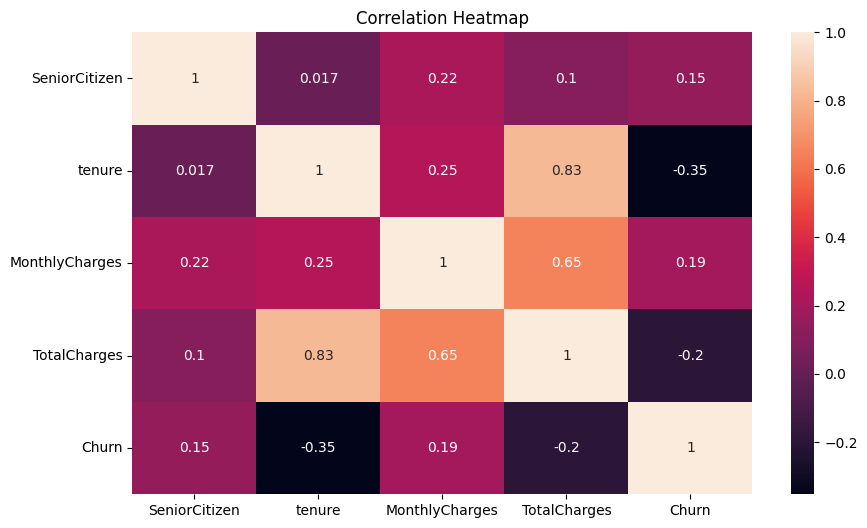

Encoding Completed
Model Training Completed

Model Accuracy: 79.63 %


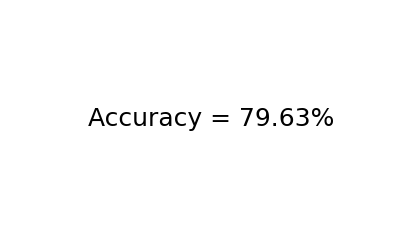

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



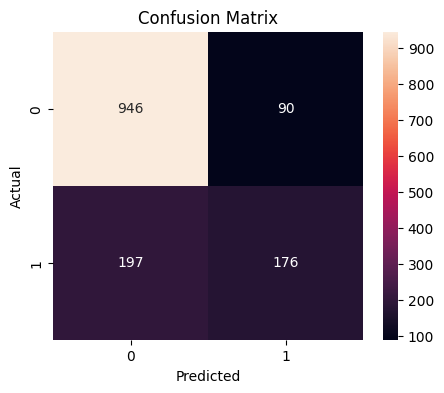

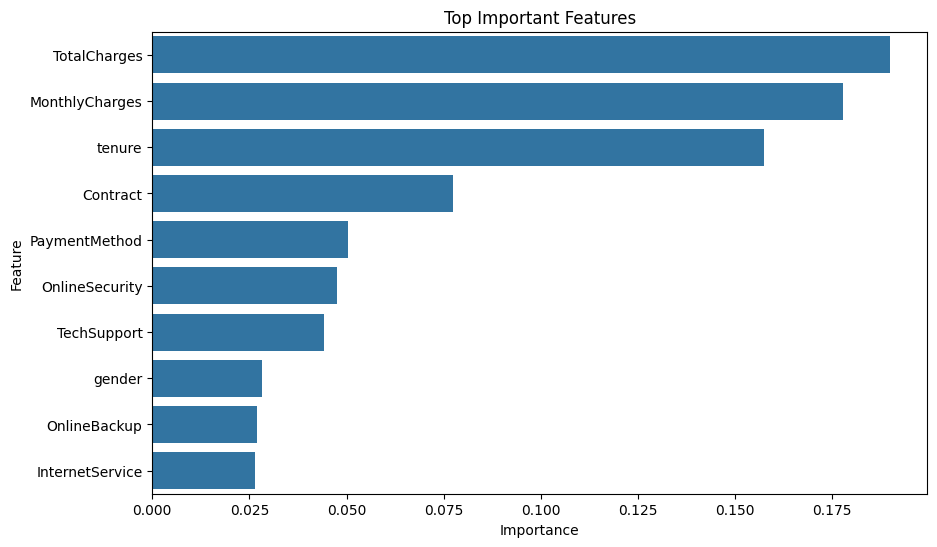

 customer_churn_dataset.csv
 customer_churn_model.pkl
scaler.pkl
 classification_report.txt
 screenshots folder


In [7]:

# CUSTOMER CHURN PREDICTION PROJECT



# Install kagglehub
!pip install kagglehub -q

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import glob
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

# CREATE FOLDERS
os.makedirs(
    "screenshots",
    exist_ok=True
)
# DOWNLOAD DATASET
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)
print("Dataset Downloaded")
print(path)
# Finding  CSV file After downloading

csv_file = glob.glob(
    path + "/*.csv"
)
print("\nCSV File:")
print(csv_file)
# Loading  dataset

df = pd.read_csv(
    csv_file[0]
)
print("\nDataset Loaded Successfully")

display(df.head())
# Saving  CSV File

df.to_csv(
    "customer_churn_dataset.csv",
    index=False
)
print("CSV Saved ")

# Data Information

print("\nDataset Shape")
print(df.shape)
print("\nMissing Values")
print(df.isnull().sum())

# Data  Cleaning



# Remove ID

df.drop(
    "customerID",
    axis=1,
    inplace=True
)



# Convert Total Charges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)



# Fill missing values

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)



# Convert target

df["Churn"] = df["Churn"].map(
    {
        "Yes":1,
        "No":0
    }
)



print("\nCleaning Completed")

display(df.head())

# EXPLORATORY DATA ANALYSIS

# Churn Distribution


plt.figure(
    figsize=(6,4)
)


sns.countplot(
    x="Churn",
    data=df
)


plt.title(
    "Customer Churn Distribution"
)


plt.savefig(
    "screenshots/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Correlation Heatmap


plt.figure(
    figsize=(10,6)
)


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)


plt.title(
    "Correlation Heatmap"
)


plt.savefig(
    "screenshots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# ENCODING
encoder = LabelEncoder()
for col in df.select_dtypes(
    include="object"
).columns:

    df[col] = encoder.fit_transform(
        df[col]
    )

print("Encoding Completed")

# SPLIT DATA


X = df.drop(
    "Churn",
    axis=1
)


y = df["Churn"]



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train
)
X_test = scaler.transform(
    X_test
)

# TRAIN RANDOM FOREST MODEL
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)
model.fit(

    X_train,

    y_train

)



print("Model Training Completed")

# PREDICTION

prediction = model.predict(
    X_test
)



accuracy = accuracy_score(

    y_test,

    prediction

)



print(
    "\nModel Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)




# Save Accuracy Image


plt.figure(
    figsize=(5,3)
)


plt.text(
    0.2,
    0.5,
    f"Accuracy = {accuracy*100:.2f}%",
    fontsize=18
)


plt.axis("off")


plt.savefig(
    "screenshots/model_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# CLASSIFICATION REPORT



report = classification_report(
    y_test,
    prediction
)


print(report)



with open(
    "classification_report.txt",
    "w"
) as file:

    file.write(report)

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    prediction
)



plt.figure(
    figsize=(5,4)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Confusion Matrix"
)


plt.savefig(
    "screenshots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()
# FEATURE IMPORTANCE

importance = pd.DataFrame(

    {
        "Feature":X.columns,
        "Importance":model.feature_importances_
    }

)



importance = importance.sort_values(

    by="Importance",

    ascending=False

)
plt.figure(
    figsize=(10,6)
)
sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(10)

)
plt.title(
    "Top Important Features"
)
plt.savefig(
    "screenshots/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()

# SAVE MODEL
pickle.dump(

    model,

    open(
        "customer_churn_model.pkl",
        "wb"
    )

)



pickle.dump(

    scaler,

    open(
        "scaler.pkl",
        "wb"
    )

)





print(" customer_churn_dataset.csv")
print(" customer_churn_model.pkl")
print("scaler.pkl")
print(" classification_report.txt")
print(" screenshots folder")

